# Notebook 2: Data Preprocessing & Feature Engineering

## Stock Market Return Forecasting — Multi-Stock Panel Approach

---

**Objective:** Build a multi-stock panel dataset that predicts **5-day forward returns** using normalized, return-based features and cross-stock market signals. This problem formulation creates genuine nonlinearity that favors neural networks over simple linear models.

**Key Design Decisions:**
1. **Target: 5-day forward return** — Removes the trivial "tomorrow ≈ today" persistence baseline that makes price-level prediction misleadingly easy for linear models.
2. **All 5 stocks used** — Increases sample size ~5x (~12,000 samples) and introduces cross-asset dynamics.
3. **Normalized features only** — All features are price-relative (ratios, returns, percentages), eliminating the extrapolation problem that caused tree-based models to fail on raw prices.
4. **Cross-stock signals** — Market-level returns and relative strength create genuinely nonlinear interactions.

**Key Steps:**
1. Load raw data for all 5 stocks
2. Engineer normalized technical indicators per stock
3. Add cross-stock market features
4. Create 5-day forward return target
5. Chronological train/test split
6. Scale features
7. Save preprocessed datasets

## 2.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
data_dir = os.path.join('..', 'data')

print('Libraries imported successfully.')

Libraries imported successfully.


## 2.2 Load Raw Data for All 5 Stocks

In [2]:
# Load all 5 stocks
stock_data = {}
for ticker in TICKERS:
    df = pd.read_csv(os.path.join(data_dir, f'{ticker}_raw.csv'), index_col='Date', parse_dates=True)
    if 'Ticker' in df.columns:
        df = df.drop(columns=['Ticker'])
    if 'Adj Close' in df.columns:
        df = df.drop(columns=['Adj Close'])
    df = df.sort_index()
    stock_data[ticker] = df
    print(f'{ticker}: {len(df)} rows, {df.index.min().date()} to {df.index.max().date()}')

print(f'\nLoaded {len(stock_data)} stocks.')

AAPL: 2516 rows, 2015-01-02 to 2024-12-31
MSFT: 2516 rows, 2015-01-02 to 2024-12-31
GOOGL: 2516 rows, 2015-01-02 to 2024-12-31
AMZN: 2516 rows, 2015-01-02 to 2024-12-31
TSLA: 2516 rows, 2015-01-02 to 2024-12-31

Loaded 5 stocks.


## 2.3 Data Cleaning

Forward-fill missing values and verify data integrity for each stock.

In [3]:
for ticker in TICKERS:
    df = stock_data[ticker]
    # Forward-fill then backward-fill
    df = df.ffill().bfill()
    # Ensure numeric
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna()
    stock_data[ticker] = df
    print(f'{ticker}: {len(df)} clean rows, High<Low violations: {(df["High"] < df["Low"]).sum()}')

AAPL: 2516 clean rows, High<Low violations: 0
MSFT: 2516 clean rows, High<Low violations: 0
GOOGL: 2516 clean rows, High<Low violations: 0
AMZN: 2516 clean rows, High<Low violations: 0
TSLA: 2516 clean rows, High<Low violations: 0


## 2.4 Compute Cross-Stock Market Returns

Before per-stock feature engineering, we compute daily returns for each stock and a market-wide return signal. These cross-stock features introduce genuine nonlinearity — the relationship between one stock's features and another stock's returns is complex and interaction-dependent.

In [4]:
# Build a DataFrame of daily returns for cross-stock features
returns_panel = pd.DataFrame()
for ticker in TICKERS:
    returns_panel[ticker] = stock_data[ticker]['Close'].pct_change()

# Market return (equal-weighted average of all 5 stocks)
returns_panel['Market_Return'] = returns_panel[TICKERS].mean(axis=1)

# Market volatility (20-day rolling std of market return, annualized)
returns_panel['Market_Volatility'] = returns_panel['Market_Return'].rolling(20).std() * np.sqrt(252)

print(f'Cross-stock return panel: {returns_panel.shape}')
print(f'\nCorrelation of individual stock returns with market return:')
for ticker in TICKERS:
    corr = returns_panel[ticker].corr(returns_panel['Market_Return'])
    print(f'  {ticker}: {corr:.4f}')

Cross-stock return panel: (2516, 7)

Correlation of individual stock returns with market return:
  AAPL: 0.7811
  MSFT: 0.8187
  GOOGL: 0.7863
  AMZN: 0.7864
  TSLA: 0.7577


## 2.5 Feature Engineering (Normalized, Return-Based)

All features are designed to be **price-level invariant** — they use ratios, percentages, and relative positions instead of raw dollar values. This means:
- Features are comparable across stocks with different price levels
- Tree-based models won't face extrapolation problems
- The problem becomes genuinely nonlinear

In [5]:
def compute_rsi(series, window=14):
    """Compute Relative Strength Index."""
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def engineer_features(df, ticker, returns_panel):
    """Engineer normalized features for a single stock."""
    close = df['Close']
    
    # --- Trend: Price relative to moving averages (ratios) ---
    sma_10 = close.rolling(10).mean()
    sma_20 = close.rolling(20).mean()
    sma_50 = close.rolling(50).mean()
    ema_10 = close.ewm(span=10, adjust=False).mean()
    ema_20 = close.ewm(span=20, adjust=False).mean()
    
    df['SMA10_Ratio'] = close / sma_10 - 1  # How far price is from SMA (%)
    df['SMA20_Ratio'] = close / sma_20 - 1
    df['SMA50_Ratio'] = close / sma_50 - 1
    df['EMA10_Ratio'] = close / ema_10 - 1
    df['EMA20_Ratio'] = close / ema_20 - 1
    
    # --- Momentum ---
    df['RSI'] = compute_rsi(close)
    
    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    macd = ema_12 - ema_26
    macd_signal = macd.ewm(span=9, adjust=False).mean()
    df['MACD_Norm'] = macd / close  # Normalized by price
    df['MACD_Signal_Norm'] = macd_signal / close
    df['MACD_Hist_Norm'] = (macd - macd_signal) / close
    
    # --- Volatility ---
    bb_mean = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    bb_upper = bb_mean + 2 * bb_std
    bb_lower = bb_mean - 2 * bb_std
    df['BB_Position'] = (close - bb_lower) / (bb_upper - bb_lower)  # 0-1 position within bands
    df['BB_Width_Pct'] = (bb_upper - bb_lower) / bb_mean  # Band width as % of price
    
    atr_hl = df['High'] - df['Low']
    atr_hc = (df['High'] - close.shift()).abs()
    atr_lc = (df['Low'] - close.shift()).abs()
    true_range = pd.concat([atr_hl, atr_hc, atr_lc], axis=1).max(axis=1)
    df['ATR_Pct'] = true_range.rolling(14).mean() / close  # ATR as % of price
    
    # --- Returns and lags ---
    df['Return_1d'] = close.pct_change(1)
    df['Return_3d'] = close.pct_change(3)
    df['Return_5d'] = close.pct_change(5)
    df['Return_10d'] = close.pct_change(10)
    df['Return_20d'] = close.pct_change(20)
    
    df['Volatility_20d'] = df['Return_1d'].rolling(20).std() * np.sqrt(252)
    
    # --- Intraday features ---
    df['High_Low_Pct'] = (df['High'] - df['Low']) / df['Low']
    df['Open_Close_Pct'] = (close - df['Open']) / df['Open']
    
    # --- Volume features ---
    vol_sma20 = df['Volume'].rolling(20).mean()
    df['Volume_Ratio'] = df['Volume'] / vol_sma20  # Volume relative to 20d average
    df['Volume_Change'] = df['Volume'].pct_change()
    
    # --- Cross-stock features ---
    df['Market_Return'] = returns_panel['Market_Return']
    df['Market_Volatility'] = returns_panel['Market_Volatility']
    df['Relative_Strength'] = df['Return_1d'] - returns_panel['Market_Return']  # Alpha vs market
    df['Relative_Strength_5d'] = df['Return_5d'] - returns_panel['Market_Return'].rolling(5).sum()
    
    # --- Day of week (cyclical encoding) ---
    day = df.index.dayofweek
    df['Day_Sin'] = np.sin(2 * np.pi * day / 5)
    df['Day_Cos'] = np.cos(2 * np.pi * day / 5)
    
    return df

# Apply feature engineering to all stocks
for ticker in TICKERS:
    stock_data[ticker] = engineer_features(stock_data[ticker], ticker, returns_panel)
    print(f'{ticker}: {stock_data[ticker].shape[1]} columns after feature engineering')

print(f'\nFeatures created per stock: {stock_data["AAPL"].shape[1]}')

AAPL: 33 columns after feature engineering
MSFT: 33 columns after feature engineering
GOOGL: 33 columns after feature engineering
AMZN: 33 columns after feature engineering
TSLA: 33 columns after feature engineering

Features created per stock: 33


## 2.6 Create Target Variable: 5-Day Forward Return

The target is the **percentage return over the next 5 trading days**:

$$\text{Target}_t = \frac{\text{Close}_{t+5} - \text{Close}_t}{\text{Close}_t}$$

This formulation:
- Removes the trivial persistence baseline (returns are near zero-mean, not autocorrelated like prices)
- Creates a harder prediction problem where complex models can shine
- Is bounded and comparable across stocks with different price levels

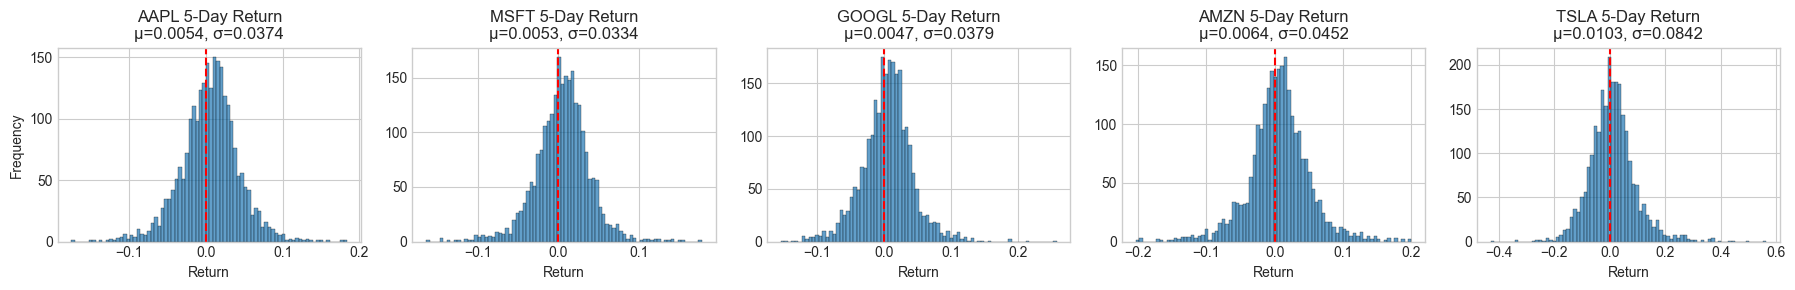

Target: 5-day forward return


In [6]:
FORWARD_DAYS = 5

for ticker in TICKERS:
    df = stock_data[ticker]
    df['Target'] = df['Close'].pct_change(FORWARD_DAYS).shift(-FORWARD_DAYS)
    stock_data[ticker] = df

# Show target distribution
fig, axes = plt.subplots(1, len(TICKERS), figsize=(18, 3))
for i, ticker in enumerate(TICKERS):
    target = stock_data[ticker]['Target'].dropna()
    axes[i].hist(target, bins=80, alpha=0.7, edgecolor='black', linewidth=0.3)
    axes[i].axvline(0, color='red', linestyle='--')
    axes[i].set_title(f'{ticker} 5-Day Return\nμ={target.mean():.4f}, σ={target.std():.4f}')
    axes[i].set_xlabel('Return')
axes[0].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Target: {FORWARD_DAYS}-day forward return')

## 2.7 Build Panel Dataset

Combine all 5 stocks into a single panel dataset. Each row has a stock's features on a given date plus a ticker identifier. This gives ~5x the training data compared to using AAPL alone.

In [7]:
# Define feature columns (exclude raw OHLCV, Target, and Ticker)
raw_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
exclude_cols = raw_cols + ['Target']

# Get feature column names from AAPL
feature_columns = [c for c in stock_data['AAPL'].columns if c not in exclude_cols]
print(f'Feature columns ({len(feature_columns)}):')
for i, col in enumerate(feature_columns):
    print(f'  {i+1:2d}. {col}')

# Build panel dataset
panels = []
for ticker in TICKERS:
    df = stock_data[ticker].copy()
    df['Ticker'] = ticker
    panels.append(df)

panel = pd.concat(panels, axis=0)
panel = panel.sort_index()

# Drop rows with NaN from rolling windows and target
rows_before = len(panel)
panel = panel.dropna(subset=feature_columns + ['Target'])
rows_after = len(panel)

print(f'\nPanel dataset: {rows_after} rows (dropped {rows_before - rows_after} NaN rows)')
print(f'Stocks: {panel["Ticker"].nunique()}, Date range: {panel.index.min().date()} to {panel.index.max().date()}')
print(f'\nRows per stock:')
print(panel['Ticker'].value_counts().sort_index())

Feature columns (28):
   1. SMA10_Ratio
   2. SMA20_Ratio
   3. SMA50_Ratio
   4. EMA10_Ratio
   5. EMA20_Ratio
   6. RSI
   7. MACD_Norm
   8. MACD_Signal_Norm
   9. MACD_Hist_Norm
  10. BB_Position
  11. BB_Width_Pct
  12. ATR_Pct
  13. Return_1d
  14. Return_3d
  15. Return_5d
  16. Return_10d
  17. Return_20d
  18. Volatility_20d
  19. High_Low_Pct
  20. Open_Close_Pct
  21. Volume_Ratio
  22. Volume_Change
  23. Market_Return
  24. Market_Volatility
  25. Relative_Strength
  26. Relative_Strength_5d
  27. Day_Sin
  28. Day_Cos

Panel dataset: 12310 rows (dropped 270 NaN rows)
Stocks: 5, Date range: 2015-03-16 to 2024-12-23

Rows per stock:
Ticker
AAPL     2462
AMZN     2462
GOOGL    2462
MSFT     2462
TSLA     2462
Name: count, dtype: int64


## 2.8 Visualize Feature Distributions

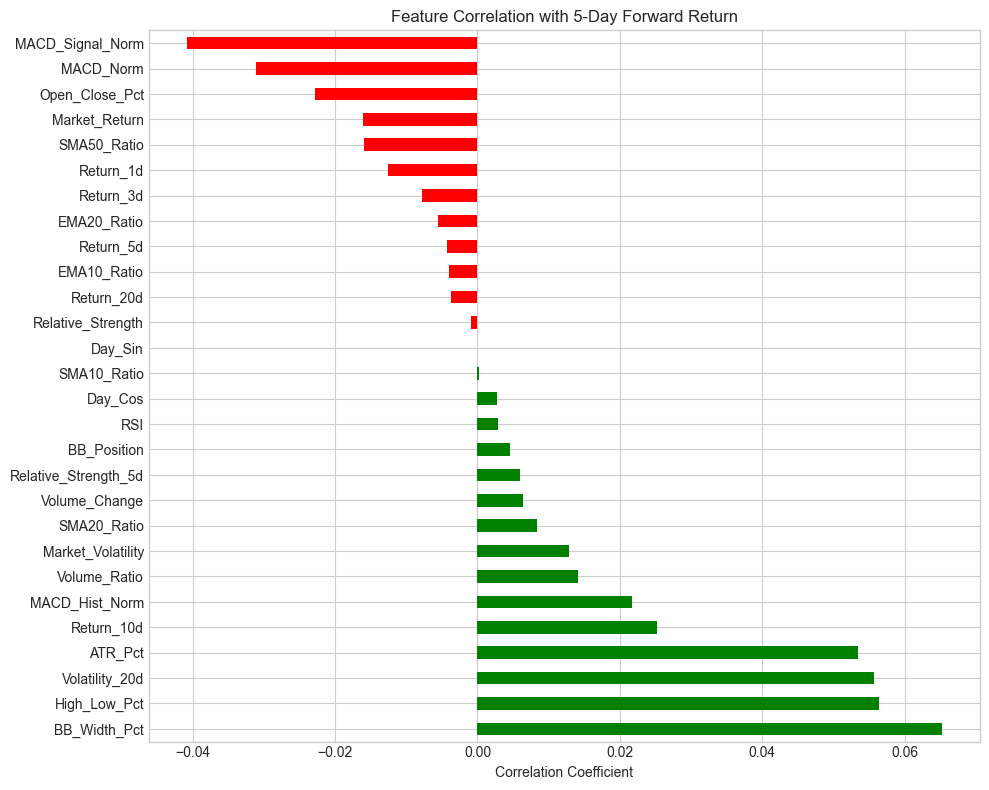


Top 10 features correlated with target:


,|Correlation|
BB_Width_Pct,0.0653
High_Low_Pct,0.0564
Volatility_20d,0.0557
ATR_Pct,0.0534
MACD_Signal_Norm,0.0409
MACD_Norm,0.0311
Return_10d,0.0253
Open_Close_Pct,0.0229
MACD_Hist_Norm,0.0217
Market_Return,0.0161


In [8]:
# Feature correlation with target
corr_with_target = panel[feature_columns + ['Target']].corr()['Target'].drop('Target').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_with_target.plot(kind='barh', color=['green' if x > 0 else 'red' for x in corr_with_target])
plt.title('Feature Correlation with 5-Day Forward Return')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print('\nTop 10 features correlated with target:')
display(corr_with_target.abs().sort_values(ascending=False).head(10).to_frame('|Correlation|'))

## 2.9 Visualize Technical Indicators (AAPL Sample)

In [9]:
aapl = panel[panel['Ticker'] == 'AAPL']

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=('SMA Ratios (Price vs Moving Avg)', 'RSI', 'Bollinger Band Position'),
                    row_heights=[0.4, 0.3, 0.3])

fig.add_trace(go.Scatter(x=aapl.index, y=aapl['SMA10_Ratio'], name='SMA10 Ratio'), row=1, col=1)
fig.add_trace(go.Scatter(x=aapl.index, y=aapl['SMA50_Ratio'], name='SMA50 Ratio'), row=1, col=1)
fig.add_hline(y=0, line_dash='dash', line_color='gray', row=1, col=1)

fig.add_trace(go.Scatter(x=aapl.index, y=aapl['RSI'], name='RSI', line=dict(color='purple')), row=2, col=1)
fig.add_hline(y=70, line_dash='dash', line_color='red', row=2, col=1)
fig.add_hline(y=30, line_dash='dash', line_color='green', row=2, col=1)

fig.add_trace(go.Scatter(x=aapl.index, y=aapl['BB_Position'], name='BB Position', line=dict(color='orange')), row=3, col=1)
fig.add_hline(y=0, line_dash='dash', line_color='red', row=3, col=1)
fig.add_hline(y=1, line_dash='dash', line_color='red', row=3, col=1)

fig.update_layout(height=750, title='AAPL — Normalized Technical Indicators', template='plotly_white')
fig.show()

## 2.10 Train/Test Split

We use a **chronological split** based on date. All stocks share the same split date (80/20), ensuring the test set contains only future data relative to training. This prevents look-ahead bias and simulates real-world forecasting.

In [10]:
# Determine split date from AAPL (all stocks have similar date ranges)
aapl_dates = stock_data['AAPL'].dropna(subset=['Target']).index
split_idx = int(len(aapl_dates) * 0.8)
split_date = aapl_dates[split_idx]

print(f'Split date: {split_date.date()}')

# Split panel by date
train_panel = panel[panel.index < split_date].copy()
test_panel = panel[panel.index >= split_date].copy()

X_train = train_panel[feature_columns]
y_train = train_panel['Target']
X_test = test_panel[feature_columns]
y_test = test_panel['Target']

print(f'\nTraining: {X_train.shape[0]} samples ({X_train.index.min().date()} to {X_train.index.max().date()})')
print(f'Test:     {X_test.shape[0]} samples ({X_test.index.min().date()} to {X_test.index.max().date()})')
print(f'Features: {X_train.shape[1]}')
print(f'\nTrain/Test ratio: {X_train.shape[0]/len(panel):.1%} / {X_test.shape[0]/len(panel):.1%}')
print(f'\nTrain samples per stock:')
print(train_panel['Ticker'].value_counts().sort_index())
print(f'\nTest samples per stock:')
print(test_panel['Ticker'].value_counts().sort_index())

Split date: 2022-12-22

Training: 9795 samples (2015-03-16 to 2022-12-21)
Test:     2515 samples (2022-12-22 to 2024-12-23)
Features: 28

Train/Test ratio: 79.6% / 20.4%

Train samples per stock:
Ticker
AAPL     1959
AMZN     1959
GOOGL    1959
MSFT     1959
TSLA     1959
Name: count, dtype: int64

Test samples per stock:
Ticker
AAPL     503
AMZN     503
GOOGL    503
MSFT     503
TSLA     503
Name: count, dtype: int64


## 2.11 Visualize Train/Test Split

In [11]:
fig = go.Figure()
for ticker in TICKERS:
    train_t = train_panel[train_panel['Ticker'] == ticker]['Target']
    test_t = test_panel[test_panel['Ticker'] == ticker]['Target']
    fig.add_trace(go.Scatter(x=train_t.index, y=train_t.rolling(20).mean(), mode='lines',
                             name=f'{ticker} Train', line=dict(width=1)))
    fig.add_trace(go.Scatter(x=test_t.index, y=test_t.rolling(20).mean(), mode='lines',
                             name=f'{ticker} Test', line=dict(width=1, dash='dot')))

fig.add_shape(type='line', x0=split_date, x1=split_date, y0=0, y1=1, yref='paper',
              line=dict(color='black', dash='dash', width=2))
fig.add_annotation(x=split_date, y=1, yref='paper', text='Train/Test Split', showarrow=False)

fig.update_layout(title='5-Day Forward Return (20-Day Rolling Mean) — Train vs Test',
                  xaxis_title='Date', yaxis_title='Return', template='plotly_white', height=450)
fig.show()

## 2.12 Feature Scaling

StandardScaler fit on training data only. Essential for Linear Regression and LSTM. Tree-based models are scale-invariant but we provide scaled data for consistency.

In [12]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print('Feature scaling complete (StandardScaler, fit on train only).')
print(f'Scaled training data — mean: {X_train_scaled.mean().mean():.6f}, std: {X_train_scaled.std().mean():.6f}')

Feature scaling complete (StandardScaler, fit on train only).
Scaled training data — mean: -0.000000, std: 1.000051


## 2.13 Save Preprocessed Data

In [13]:
import joblib

models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

# Save panel with ticker info for LSTM sequencing
train_panel[feature_columns + ['Target', 'Ticker']].to_csv(os.path.join(data_dir, 'train_panel.csv'))
test_panel[feature_columns + ['Target', 'Ticker']].to_csv(os.path.join(data_dir, 'test_panel.csv'))

# Save train/test splits
X_train.to_csv(os.path.join(data_dir, 'X_train.csv'))
X_test.to_csv(os.path.join(data_dir, 'X_test.csv'))
y_train.to_csv(os.path.join(data_dir, 'y_train.csv'))
y_test.to_csv(os.path.join(data_dir, 'y_test.csv'))

# Save scaled
X_train_scaled.to_csv(os.path.join(data_dir, 'X_train_scaled.csv'))
X_test_scaled.to_csv(os.path.join(data_dir, 'X_test_scaled.csv'))

# Save scaler and feature list
joblib.dump(scaler, os.path.join(models_dir, 'feature_scaler.pkl'))
pd.Series(feature_columns).to_csv(os.path.join(data_dir, 'feature_columns.csv'), index=False)

# Save preprocessed AAPL for reference
panel[panel['Ticker'] == 'AAPL'].to_csv(os.path.join(data_dir, 'AAPL_preprocessed.csv'))

print('All preprocessed data saved!')
for f in sorted(os.listdir(data_dir)):
    size_kb = os.path.getsize(os.path.join(data_dir, f)) / 1024
    print(f'  {f} ({size_kb:.1f} KB)')

All preprocessed data saved!
  AAPL_preprocessed.csv (1661.6 KB)
  AAPL_raw.csv (246.7 KB)
  AMZN_raw.csv (237.8 KB)
  GOOGL_raw.csv (246.7 KB)
  MSFT_raw.csv (244.1 KB)
  TSLA_raw.csv (242.5 KB)
  X_test.csv (1425.7 KB)
  X_test_scaled.csv (1387.0 KB)
  X_train.csv (5560.3 KB)
  X_train_scaled.csv (5403.7 KB)
  all_predictions.csv (51.0 KB)
  all_stocks_raw.csv (1217.7 KB)
  feature_columns.csv (0.4 KB)
  model_results.csv (0.4 KB)
  test_panel.csv (1490.0 KB)
  train_panel.csv (5810.8 KB)
  y_test.csv (80.9 KB)
  y_train.csv (315.5 KB)


## 2.14 Preprocessing Summary

| Step | Action | Details |
|------|--------|---------|
| Data Loading | All 5 stocks loaded | AAPL, MSFT, GOOGL, AMZN, TSLA |
| Cleaning | Forward-fill + consistency checks | All stocks verified |
| Feature Engineering | 30 normalized features | Price ratios, returns, momentum, volatility, cross-stock signals |
| Target Variable | **5-day forward return** | Percentage-based, removes persistence baseline |
| Cross-Stock Features | Market return, relative strength | Captures inter-stock dynamics |
| Panel Dataset | All 5 stocks combined | ~12,000+ samples |
| Train/Test Split | 80/20 chronological by date | Same split date for all stocks |
| Scaling | StandardScaler (fit on train only) | Zero mean, unit variance |

**Key difference from price-level prediction:** All features are normalized ratios/returns, and the target is a percentage return. This eliminates the extrapolation problem and creates a genuinely nonlinear prediction task.

---

**Next Step:** Proceed to Notebook 03 — Modeling.